In [1]:
import numpy as np
import io

def load_line_fit_parameters(filename):
    B0_fit = None
    B0_err = None
    harmonic_lines = []
    with open(filename, "r") as f:
        for line in f:
            stripped = line.strip()
            if not stripped or stripped.startswith("#"):
                continue
            if B0_fit is None:
                vals = np.fromstring(stripped, sep=" ")
                B0_fit, B0_err = vals[0], vals[1]
            else:
                harmonic_lines.append(stripped)
    harmonics = np.loadtxt(io.StringIO("\n".join(harmonic_lines)))
    if harmonics.ndim == 1:
        harmonics = harmonics[None, :]
    freqs = harmonics[:, 0]
    A_vals = harmonics[:, 1]
    A_errs = harmonics[:, 2]
    phi_vals = harmonics[:, 3]
    phi_errs = harmonics[:, 4]
    return B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs

def _get_line_params(param_file, B0, A60, phi60, A180, phi180):
    if param_file is not None:
        B0_fit, B0_err, freqs, A_vals, A_errs, phi_vals, phi_errs = load_line_fit_parameters(param_file)
        return B0_fit, freqs, A_vals, phi_vals
    freqs = np.array([60.0, 180.0], dtype=float)
    A_vals = np.array([A60, A180], dtype=float)
    phi_vals = np.array([phi60, phi180], dtype=float)
    return B0, freqs, A_vals, phi_vals
# B0 = 0.3350, A60 = -0.3204, phi60 = 0.7425, A180 = -0.0978, phi180 = -0.5812,
def B_line_mG(t, B0 = 0.3350, A60 = -0.3204, phi60 = 0.7425, A180 = -0.0978, phi180 = -0.5812, param_file = 'line_signal_fit_params.txt'):
    B0_use, freqs, A_vals, phi_vals = _get_line_params(param_file, B0, A60, phi60, A180, phi180)
    t_arr = np.asarray(t, dtype=float)
    y = np.full_like(t_arr, B0_use, dtype=float)
    for f, A, phi in zip(freqs, A_vals, phi_vals):
        y = y + A * np.cos(2.0 * np.pi * f * t_arr + phi)
    return y


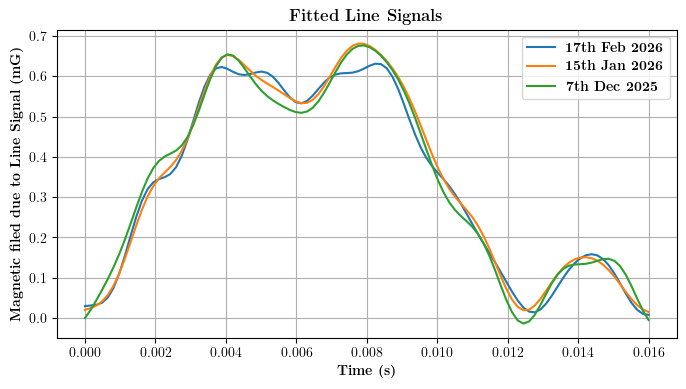

In [2]:
import matplotlib.pyplot as plt
from matplotlib import rcParams
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['Computer Modern']
rcParams['text.usetex'] = True
rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'

plt.figure(figsize = (8,4))
times = np.linspace(0, 16000e-6, 100)
plt.plot(times, B_line_mG(times), label = r'\textbf{17th Feb 2026}')
plt.plot(times, B_line_mG(times, param_file = 'line_signal_fit_params_20260115.txt'), label = r'\textbf{15th Jan 2026}')
plt.plot(times, B_line_mG(times, param_file = 'line_signal_fit_params_20251207.txt') - B_line_mG(0, param_file = 'line_signal_fit_params_20251207.txt'), label = r'\textbf{7th Dec 2025}')
plt.legend()
plt.xlabel(r'\textbf{Time (s)}')
plt.ylabel(r'\textbf{Magnetic filed due to Line Signal (mG)}')
plt.title(r'\textbf{Fitted Line Signals}')
plt.grid()
plt.show()

In [3]:
from scipy import integrate as int

val, err = int.quad(B_line_mG, 0, 1000e-6) 

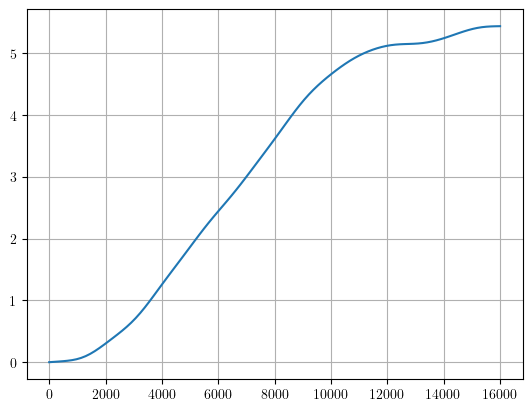

In [7]:
int_vals = []

for i in times:
    val, err = int.quad(B_line_mG, 0, i)
    int_vals.append(val)

plt.figure()
plt.plot(times*1e6, np.array(int_vals)*1e3)
plt.grid()
plt.show()


In [5]:
display(np.array(times))

array([0.        , 0.00016162, 0.00032323, 0.00048485, 0.00064646,
       0.00080808, 0.0009697 , 0.00113131, 0.00129293, 0.00145455,
       0.00161616, 0.00177778, 0.00193939, 0.00210101, 0.00226263,
       0.00242424, 0.00258586, 0.00274747, 0.00290909, 0.00307071,
       0.00323232, 0.00339394, 0.00355556, 0.00371717, 0.00387879,
       0.0040404 , 0.00420202, 0.00436364, 0.00452525, 0.00468687,
       0.00484848, 0.0050101 , 0.00517172, 0.00533333, 0.00549495,
       0.00565657, 0.00581818, 0.0059798 , 0.00614141, 0.00630303,
       0.00646465, 0.00662626, 0.00678788, 0.00694949, 0.00711111,
       0.00727273, 0.00743434, 0.00759596, 0.00775758, 0.00791919,
       0.00808081, 0.00824242, 0.00840404, 0.00856566, 0.00872727,
       0.00888889, 0.00905051, 0.00921212, 0.00937374, 0.00953535,
       0.00969697, 0.00985859, 0.0100202 , 0.01018182, 0.01034343,
       0.01050505, 0.01066667, 0.01082828, 0.0109899 , 0.01115152,
       0.01131313, 0.01147475, 0.01163636, 0.01179798, 0.01195

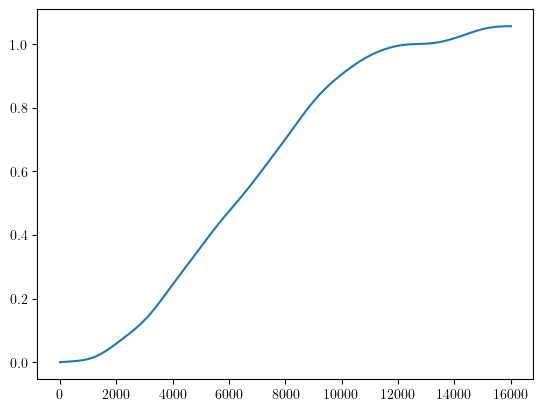

In [6]:
plt.figure()
plt.plot(times*1e6, np.mod(2*0.0971*np.array(int_vals)*1e3, 2))
plt.show()


In [ ]:
#!/usr/bin/env python3
import threading
import time
import math
import queue
import cv2
import numpy as np
from flask import Flask, Response
from influxdb import InfluxDBClient

DEVICE = "/dev/video0"
WIDTH = 640
HEIGHT = 480
FPS = 20
JPEG_QUALITY = 80

BLUR_KERNEL = 21
THRESHOLD_FRAC = 0.50
MIN_PIXELS = 30

INFLUX_HOST = "192.168.168.24"
INFLUX_PORT = 8086
INFLUX_DB = "lab_HPT"
MEASUREMENT = "laser_drift"

LOG_EVERY_N_FRAMES = 10

app = Flask(__name__)

lock = threading.Lock()
latest_jpeg = None
reference_center = None
frame_counter = 0

log_queue = queue.Queue(maxsize=1000)

client = InfluxDBClient(
    host=INFLUX_HOST,
    port=INFLUX_PORT,
    database=INFLUX_DB,
    timeout=1,
    retries=0
)


def logger_loop():
    while True:
        point = log_queue.get()
        try:
            client.write_points([point])
        except Exception as e:
            print("InfluxDB write error:", e)
        finally:
            log_queue.task_done()


def capture_loop():
    global latest_jpeg, reference_center, frame_counter

    cap = cv2.VideoCapture(DEVICE, cv2.CAP_V4L2)
    if not cap.isOpened():
        raise RuntimeError(f"Could not open {DEVICE}")

    fourcc = cv2.VideoWriter_fourcc(*"MJPG")
    cap.set(cv2.CAP_PROP_FOURCC, fourcc)
    cap.set(cv2.CAP_PROP_FRAME_WIDTH, WIDTH)
    cap.set(cv2.CAP_PROP_FRAME_HEIGHT, HEIGHT)
    cap.set(cv2.CAP_PROP_FPS, FPS)

    while True:
        ok, frame = cap.read()
        if not ok or frame is None:
            time.sleep(0.05)
            continue

        display = frame.copy()
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        blur = cv2.GaussianBlur(gray, (BLUR_KERNEL, BLUR_KERNEL), 0)

        peak = float(blur.max())
        thresh_val = max(30, int(THRESHOLD_FRAC * peak))
        _, mask = cv2.threshold(blur, thresh_val, 255, cv2.THRESH_BINARY)

        kernel = np.ones((5, 5), np.uint8)
        mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
        mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

        ys, xs = np.nonzero(mask)
        h, w = display.shape[:2]

        if len(xs) >= MIN_PIXELS:
            weights = blur[ys, xs].astype(np.float64)
            s = weights.sum()

            if s > 0:
                cx = float((xs * weights).sum() / s)
                cy = float((ys * weights).sum() / s)

                if reference_center is None:
                    reference_center = (cx, cy)

                dx = cx - reference_center[0]
                dy = cy - reference_center[1]
                drift_r = math.sqrt(dx * dx + dy * dy)

                cv2.circle(display, (int(cx), int(cy)), 8, (0, 255, 0), -1)
                cv2.putText(
                    display,
                    f"x={cx:.1f} y={cy:.1f} dx={dx:.2f} dy={dy:.2f}",
                    (20, 30),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    (0, 255, 0),
                    2,
                    cv2.LINE_AA,
                )

                frame_counter += 1
                if frame_counter % LOG_EVERY_N_FRAMES == 0:
                    point = {
                        "measurement": MEASUREMENT,
                        "tags": {
                            "camera": "usb_cam",
                            "location": "open_air"
                        },
                        "fields": {
                            "x": cx,
                            "y": cy,
                            "dx": dx,
                            "dy": dy,
                            "drift_r": drift_r,
                            "threshold": float(thresh_val),
                            "peak": peak,
                            "area_px": float(len(xs))
                        }
                    }
                    try:
                        log_queue.put_nowait(point)
                    except queue.Full:
                        print("Log queue full, dropping point")

        cv2.drawMarker(
            display,
            (w // 2, h // 2),
            (255, 0, 0),
            markerType=cv2.MARKER_CROSS,
            markerSize=20,
            thickness=2,
        )

        ok, buf = cv2.imencode(".jpg", display, [int(cv2.IMWRITE_JPEG_QUALITY), JPEG_QUALITY])
        if ok:
            with lock:
                latest_jpeg = buf.tobytes()


def mjpeg_generator():
    while True:
        with lock:
            frame = latest_jpeg
        if frame is None:
            time.sleep(0.02)
            continue
        yield (
            b"--frame\r\n"
            b"Content-Type: image/jpeg\r\n\r\n" + frame + b"\r\n"
        )
        time.sleep(1 / FPS)


@app.route("/")
def index():
    return '<html><body style="background:#111;text-align:center;"><img src="/video_feed" width="80%"></body></html>'


@app.route("/video_feed")
def video_feed():
    return Response(mjpeg_generator(), mimetype="multipart/x-mixed-replace; boundary=frame")


if __name__ == "__main__":
    threading.Thread(target=logger_loop, daemon=True).start()
    threading.Thread(target=capture_loop, daemon=True).start()
    app.run(host="0.0.0.0", port=5000, threaded=True)